# Implementing Decision Trees from Scratch

In this tutorial, you'll build a decision tree classifier from the ground up using only NumPy. By the end, you'll understand how decision trees actually work. No library magic, just the math and the logic.

**Prerequisites:** Basic Python and a little NumPy (creating arrays, indexing).

**What we'll cover:**

1. What decision trees are and how they make predictions
2. Measuring how "mixed" a node is — entropy and Gini index
3. Splitting data on features
4. Choosing the best split using information gain
5. Building the tree recursively
6. Training on a real dataset and evaluating accuracy

Let's get started.

## What is a decision tree?

A decision tree makes predictions by asking a series of yes/no questions about the input. Each internal node tests one feature; each branch is a possible answer; each leaf is a final prediction.

For example, imagine deciding whether to bring an umbrella:

- Is it raining? → If yes, bring umbrella. If no, check the next question.
- Are dark clouds present? → If yes, bring umbrella. If no, leave it.

Each question splits the data into smaller groups. The tree keeps splitting until each group is pure enough to make a confident prediction.

**The challenge:** how do we decide *which* question to ask at each node? That's what most of this tutorial is about.

In [28]:
import numpy as np

## Measuring impurity

To decide where to split, we need a way to measure how "mixed" the labels in a group are. A pure group has all one class; an impure group has labels mixed together.

We'll use two common impurity measures:

**Entropy** — from information theory. Measures the unpredictability of the labels.

$$H(p) = -p \log_2(p) - (1-p) \log_2(1-p)$$

Where $p$ is the fraction of positive examples. Entropy is 0 when the group is pure and 1 when classes are exactly split 50/50.

**Gini index** — measures the probability of misclassifying a randomly chosen example.

$$G(p) = 1 - p^2 - (1-p)^2 = 2p(1-p)$$

Both behave similarly. Gini is faster to compute (no log), entropy has cleaner information-theoretic meaning. We'll implement both and use them interchangeably.

In [49]:
def compute_entropy(Y):
    """
    Compute the entropy of a binary label array.

    Entropy measures the impurity/disorder of a node. It's 0 when all labels
    are the same (pure) and 1 when classes are perfectly balanced (max disorder).

    Formula: H(p) = -p log2(p) - (1-p) log2(1-p)

    Args:
        Y (np.ndarray): Array of binary labels (0s and 1s)

    Returns:
        float: Entropy value in [0, 1]
    """
    # Empty node has no impurity
    if len(Y) == 0:
        return 0

    # Fraction of positive examples
    p = sum(Y) / len(Y)

    # If all examples are one class, entropy is 0 (pure node)
    # We check this to avoid log(0) which is undefined
    if p == 0 or p == 1:
        return 0

    return -p * np.log2(p) - (1 - p) * np.log2(1 - p)

In [50]:
def compute_gini_index(Y):
    """
    Compute the Gini index of a binary label array.

    Gini measures the probability of misclassifying a randomly chosen example
    if labeled randomly according to the distribution. It's 0 for pure nodes
    and 0.5 for perfectly balanced binary classification.

    Formula: G(p) = 1 - p^2 - (1-p)^2

    Args:
        Y (np.ndarray): Array of binary labels (0s and 1s)

    Returns:
        float: Gini index in [0, 0.5] for binary classification
    """
    if len(Y) == 0:
        return 0

    # Fraction of positive examples
    p = sum(Y) / len(Y)

    return 1 - p**2 - (1 - p)**2

## Splitting the dataset

Given a feature, we split the data into two groups: examples where the feature is 1 (left), and examples where it's 0 (right).

We track examples by their *indices* in the dataset rather than copying data around. This is more efficient and lets us refer back to the original data anytime.

In [51]:
def split_dataset(X, node_indices, feature_idx):
    """
    Split the dataset on a specific feature.

    Examples where the feature value is 1 go to the left child;
    examples where it's 0 go to the right child.

    We track examples by their original indices instead of copying data.
    This is more memory-efficient and lets us refer back to the original
    dataset throughout the tree.

    Args:
        X (np.ndarray): The full feature matrix, shape (n_samples, n_features)
        node_indices (list): Indices of examples in the current node
        feature_idx (int): Which feature to split on

    Returns:
        tuple: (left_indices, right_indices) — lists of example indices
    """
    left_indices = []
    right_indices = []

    # Walk through each example at this node and assign it to left or right
    for i in node_indices:
        if X[i][feature_idx] == 1:
            left_indices.append(i)
        else:
            right_indices.append(i)

    return left_indices, right_indices

## Information gain

When we split a node, impurity should decrease. The amount of decrease is **information gain**:

$$\text{Information Gain} = H(\text{parent}) - \left[w_\text{left} H(\text{left}) + w_\text{right} H(\text{right})\right]$$

Where $w_\text{left}$ and $w_\text{right}$ are the fractions of examples going to each child. We pick the split that gives the highest information gain.

The function below works with either impurity measure (entropy or Gini) by accepting it as a parameter.

In [52]:
def compute_information_gain(X, Y, node_indices, feature_idx, impurity_fn):
    """
    Compute the information gain from splitting on a feature.

    Information gain measures how much impurity decreases after splitting.
    Higher gain means the split produces purer child nodes — which is what
    we want. The feature with the highest gain is the best one to split on.

    Formula:
        IG = H(parent) - [w_left * H(left) + w_right * H(right)]

    Where w_left and w_right are the fractions of examples going to each side.

    Args:
        X (np.ndarray): Full feature matrix
        Y (np.ndarray): Full label array
        node_indices (list): Indices at the current node
        feature_idx (int): Feature to evaluate
        impurity_fn (callable): Either compute_entropy or compute_gini_index

    Returns:
        float: Information gain (always >= 0)
    """
    # Split the examples on this feature
    left_indices, right_indices = split_dataset(X, node_indices, feature_idx)

    # Extract labels for the parent and each child
    Y_node = Y[node_indices]
    Y_left = Y[left_indices]
    Y_right = Y[right_indices]

    # Number of examples at this node (used for weighting)
    n = len(node_indices)

    # Impurity before splitting
    h_node = impurity_fn(Y_node)

    # Weighted impurity after splitting (each side weighted by its size)
    w_left = len(left_indices) / n
    w_right = len(right_indices) / n
    weighted_impurity = w_left * impurity_fn(Y_left) + w_right * impurity_fn(Y_right)

    # The reduction in impurity is the information gain
    return h_node - weighted_impurity

## Choosing the best split

At each node, we evaluate every feature and pick the one with the highest information gain. We also skip features that don't actually split the data (all examples go to one side).

In [53]:
def get_best_split(X, Y, node_indices, feature_names, impurity_fn):
    """
    Find the feature that gives the highest information gain.

    For each feature, we:
    1. Split the data on it
    2. Skip if the split doesn't actually divide the data (all to one side)
    3. Compute information gain
    4. Track the best

    Args:
        X (np.ndarray): Feature matrix
        Y (np.ndarray): Labels
        node_indices (list): Indices at the current node
        feature_names (list): Names of features (for indexing)
        impurity_fn (callable): Impurity function to use

    Returns:
        tuple: (best_feature_idx, max_info_gain)
               Returns (-1, 0) if no useful split exists
    """
    best_idx = -1
    max_info_gain = 0

    # Try splitting on every feature
    for feature_idx in range(len(feature_names)):
        left_indices, right_indices = split_dataset(X, node_indices, feature_idx)

        # Skip features where all examples go to one side — that's not a real split
        if len(left_indices) == 0 or len(right_indices) == 0:
            continue

        # Compute how good this split is
        info_gain = compute_information_gain(X, Y, node_indices, feature_idx, impurity_fn)

        # Track the best one
        if info_gain > max_info_gain:
            max_info_gain = info_gain
            best_idx = feature_idx

    return best_idx, max_info_gain

## Building the tree recursively

Now we put it together. Starting from the root with all examples, we:

1. Find the best feature to split on
2. Split the data into left and right groups
3. Recursively build a tree for each side

We stop splitting when:

- The node is pure (all one class)
- No useful split exists (information gain ≤ 0)
- We've reached the maximum depth

This recursive structure is what gives decision trees their characteristic tree shape.

In [54]:
def build_tree(X, Y, node_indices, feature_names, impurity_fn, max_depth=32, current_depth=0, tree=None):
    """
    Recursively build a decision tree using a top-down greedy approach.

    At each node, we find the best feature to split on, divide the data,
    then recurse on each side. The recursion stops when:
        - We hit max_depth
        - The node has no examples
        - All examples have the same label (pure node)
        - No split provides positive information gain
        - A candidate split produces an empty side

    Args:
        X (np.ndarray): Feature matrix
        Y (np.ndarray): Labels
        node_indices (list): Indices at the current node
        feature_names (list): Names of features
        impurity_fn (callable): compute_entropy or compute_gini_index
        max_depth (int): Maximum depth of the tree (regularization)
        current_depth (int): Current depth in the recursion (internal use)
        tree (list): Accumulator that collects all splits (internal use)

    Returns:
        list: A list of split records describing the tree structure
    """
    # Initialize the tree list on the first call (avoids mutable default argument bug)
    if tree is None:
        tree = []

    # Labels at the current node
    Y_node = Y[node_indices]

    # Stopping conditions
    if current_depth == max_depth:
        return tree
    if len(Y_node) == 0:
        return tree
    if len(np.unique(Y_node)) == 1:
        # Pure node: all examples have the same label, no need to split further
        return tree

    # Find the best feature to split on
    best_idx, info_gain = get_best_split(X, Y, node_indices, feature_names, impurity_fn)

    # If no split helps, stop
    if info_gain <= 0:
        return tree

    # Split the data based on the best feature
    left_indices, right_indices = split_dataset(X, node_indices, best_idx)

    # Safety check: if either side is empty, don't split
    if len(left_indices) == 0 or len(right_indices) == 0:
        return tree

    # Record this split as part of the tree
    tree.append({
        'depth': current_depth,
        'feature_idx': best_idx,
        'feature_name': feature_names[best_idx],
        'left_indices': left_indices,
        'right_indices': right_indices,
        'info_gain': info_gain
    })

    # Print the split with indentation showing depth (useful for understanding the tree)
    indent = "  " * current_depth
    print(f"{indent}Split on '{feature_names[best_idx]}' (gain={info_gain:.4f})")
    print(f"{indent}  Left:  {left_indices}")
    print(f"{indent}  Right: {right_indices}")

    # Recurse on each side, increasing depth
    build_tree(X, Y, left_indices, feature_names, impurity_fn, max_depth, current_depth + 1, tree)
    build_tree(X, Y, right_indices, feature_names, impurity_fn, max_depth, current_depth + 1, tree)

    return tree

## Try it on a small example

Let's start with a toy dataset: classifying animals as cats (1) or not-cats (0) based on three binary features.

In [37]:
X_toy = np.array([
    [1, 1, 1],
    [0, 0, 1],
    [0, 1, 0],
    [1, 0, 1],
    [1, 1, 1],
    [1, 1, 0],
    [0, 0, 0],
    [1, 1, 0],
    [0, 1, 0],
    [0, 1, 0]
])

Y_toy = np.array([1, 1, 0, 0, 1, 1, 0, 1, 0, 0])
feature_names = ['Ear Shape', 'Face Shape', 'Whiskers']
root_indices = list(range(len(X_toy)))

print("Building tree with entropy:")
tree_toy = build_tree(X_toy, Y_toy, root_indices, feature_names, compute_entropy, max_depth=2)

Building tree with entropy:
Split on 'Ear Shape' (gain=0.2781)
  Left: [0, 3, 4, 5, 7]
  Right: [1, 2, 6, 8, 9]
  Split on 'Face Shape' (gain=0.7219)
    Left: [0, 4, 5, 7]
    Right: [3]
  Split on 'Whiskers' (gain=0.7219)
    Left: [1]
    Right: [2, 6, 8, 9]


## Training on a real dataset

The toy example is useful for understanding, but let's see how this works on a more realistic dataset. We'll generate a binary classification dataset, split it into training and testing sets, train the tree, and measure accuracy.

For our tree to work with this data, all features need to be binary (0 or 1). We'll create synthetic data that's already in this form.

In [39]:
np.random.seed(42)

# Generate a synthetic binary classification dataset
n_samples = 500
n_features = 6

# Random binary features
X = np.random.randint(0, 2, size=(n_samples, n_features))

# Create a target based on a rule the tree should be able to learn
# y = 1 if (feature 0 AND feature 1) OR (feature 2 AND NOT feature 3)
Y = ((X[:, 0] & X[:, 1]) | (X[:, 2] & ~X[:, 3] & 1)).astype(int)

# Add some noise (flip 5% of labels)
noise_mask = np.random.rand(n_samples) < 0.05
Y[noise_mask] = 1 - Y[noise_mask]

print(f"Dataset shape: {X.shape}")
print(f"Class balance: {Y.mean():.2%} positive")

Dataset shape: (500, 6)
Class balance: 41.80% positive


In [40]:
# Shuffle and split into 80% train, 20% test
indices = np.random.permutation(n_samples)
split_point = int(0.8 * n_samples)

train_idx = indices[:split_point]
test_idx = indices[split_point:]

X_train, Y_train = X[train_idx], Y[train_idx]
X_test, Y_test = X[test_idx], Y[test_idx]

print(f"Training set: {len(X_train)} examples")
print(f"Test set:     {len(X_test)} examples")

Training set: 400 examples
Test set:     100 examples


In [41]:
feature_names = [f'feature_{i}' for i in range(n_features)]
train_root = list(range(len(X_train)))

print("Building tree on training data:\n")
tree = build_tree(X_train, Y_train, train_root, feature_names, compute_entropy, max_depth=5)

Building tree on training data:

Split on 'feature_2' (gain=0.1589)
  Left: [2, 3, 4, 5, 9, 10, 11, 13, 17, 18, 20, 21, 22, 24, 25, 26, 27, 28, 29, 30, 33, 34, 37, 38, 45, 46, 48, 51, 52, 58, 59, 61, 62, 63, 65, 66, 67, 69, 74, 77, 80, 83, 86, 88, 89, 91, 92, 94, 95, 96, 97, 98, 99, 100, 102, 108, 110, 114, 115, 117, 119, 124, 126, 127, 128, 129, 133, 134, 135, 136, 137, 140, 141, 142, 145, 149, 152, 158, 162, 164, 167, 170, 171, 173, 175, 176, 177, 178, 180, 181, 182, 183, 184, 185, 186, 187, 189, 190, 192, 193, 194, 195, 198, 199, 204, 209, 212, 213, 214, 217, 219, 221, 222, 223, 228, 232, 236, 238, 242, 244, 248, 251, 252, 253, 254, 255, 256, 257, 258, 259, 264, 266, 271, 272, 275, 277, 278, 280, 281, 283, 284, 287, 289, 293, 298, 299, 303, 304, 305, 306, 308, 311, 315, 316, 317, 318, 322, 323, 324, 326, 330, 331, 334, 335, 337, 338, 339, 340, 344, 345, 346, 347, 349, 350, 351, 355, 358, 360, 361, 362, 370, 376, 378, 380, 381, 382, 387, 391, 392, 393, 395, 396, 397]
  Right: [0, 1, 

## Making predictions

Building the tree gave us a list of splits. To make a prediction on a new example, we need to walk through the tree from the root, following the appropriate branch at each split, until we reach a leaf.

The structure we built earlier uses indices, which is great for training but harder to use for prediction. For a cleaner implementation, let's build a proper tree structure that can be traversed.

In [55]:
def build_tree_structured(X, Y, node_indices, feature_names, impurity_fn, max_depth=32, current_depth=0):
    """
    Build a decision tree as a nested dictionary that can be used for prediction.

    Unlike build_tree (which returns a flat list of splits), this returns a
    proper tree structure where each node is either:
        - A leaf with a prediction
        - A split with 'left' and 'right' child trees

    This structure is what we use for actually predicting on new examples,
    since we can recursively walk it.

    Args:
        Same as build_tree

    Returns:
        dict: A nested dict representing the tree.
              Leaf nodes have keys: 'type', 'prediction', 'samples'
              Split nodes have keys: 'type', 'feature_idx', 'feature_name', 'left', 'right'
    """
    Y_node = Y[node_indices]

    # Check stopping conditions — create a leaf if any apply
    if (current_depth == max_depth or
        len(Y_node) == 0 or
        len(np.unique(Y_node)) == 1):

        # Predict the majority class at this leaf
        # If empty (shouldn't happen normally), default to 0
        prediction = int(round(np.mean(Y_node))) if len(Y_node) > 0 else 0
        return {
            'type': 'leaf',
            'prediction': prediction,
            'samples': len(Y_node)
        }

    # Find the best feature to split on
    best_idx, info_gain = get_best_split(X, Y, node_indices, feature_names, impurity_fn)

    # If no useful split, create a leaf with majority prediction
    if info_gain <= 0:
        prediction = int(round(np.mean(Y_node)))
        return {
            'type': 'leaf',
            'prediction': prediction,
            'samples': len(Y_node)
        }

    # Split the data
    left_indices, right_indices = split_dataset(X, node_indices, best_idx)

    # Safety: if either side ends up empty, make this a leaf
    if len(left_indices) == 0 or len(right_indices) == 0:
        prediction = int(round(np.mean(Y_node)))
        return {
            'type': 'leaf',
            'prediction': prediction,
            'samples': len(Y_node)
        }

    # Create a split node and recursively build both subtrees
    return {
        'type': 'split',
        'feature_idx': best_idx,
        'feature_name': feature_names[best_idx],
        'left': build_tree_structured(X, Y, left_indices, feature_names, impurity_fn, max_depth, current_depth + 1),
        'right': build_tree_structured(X, Y, right_indices, feature_names, impurity_fn, max_depth, current_depth + 1)
    }

In [57]:
def predict_one(tree, x):
    """
    Predict the class of a single example by walking the tree.

    Starts at the root and follows branches based on feature values until
    reaching a leaf, where the leaf's stored prediction is returned.

    Args:
        tree (dict): A tree structure built by build_tree_structured
        x (np.ndarray): A single example's feature vector

    Returns:
        int: The predicted class (0 or 1)
    """
    # Base case: leaf node — return its prediction
    if tree['type'] == 'leaf':
        return tree['prediction']

    # Internal node: recurse into the appropriate child based on the feature value
    if x[tree['feature_idx']] == 1:
        return predict_one(tree['left'], x)
    else:
        return predict_one(tree['right'], x)


def predict(tree, X):
    """
    Predict classes for an array of examples.

    Just applies predict_one to each example.

    Args:
        tree (dict): A tree structure from build_tree_structured
        X (np.ndarray): Feature matrix, shape (n_samples, n_features)

    Returns:
        np.ndarray: Predicted classes
    """
    return np.array([predict_one(tree, x) for x in X])

## Evaluating the tree

Now we train on the training set, predict on the test set, and measure accuracy.

In [58]:
train_root = list(range(len(X_train)))
tree_model = build_tree_structured(X_train, Y_train, train_root, feature_names, compute_entropy, max_depth=5)

# Predictions
train_preds = predict(tree_model, X_train)
test_preds = predict(tree_model, X_test)

# Accuracy
train_acc = (train_preds == Y_train).mean()
test_acc = (test_preds == Y_test).mean()

print(f"Training accuracy: {train_acc:.4f}")
print(f"Test accuracy:     {test_acc:.4f}")

Training accuracy: 0.9525
Test accuracy:     0.9700


In [59]:
tree_entropy = build_tree_structured(X_train, Y_train, train_root, feature_names, compute_entropy, max_depth=5)
tree_gini = build_tree_structured(X_train, Y_train, train_root, feature_names, compute_gini_index, max_depth=5)

acc_entropy = (predict(tree_entropy, X_test) == Y_test).mean()
acc_gini = (predict(tree_gini, X_test) == Y_test).mean()

print(f"Test accuracy with entropy: {acc_entropy:.4f}")
print(f"Test accuracy with Gini:    {acc_gini:.4f}")

Test accuracy with entropy: 0.9700
Test accuracy with Gini:    0.9700


## How does max depth affect performance?

A deeper tree fits the training data better but may overfit. Let's plot training and test accuracy for different depths.

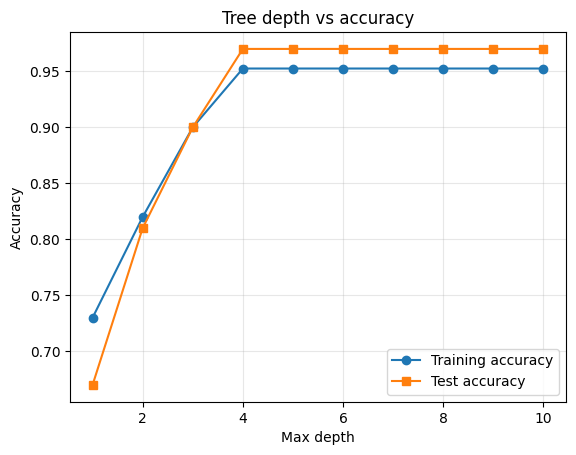

In [60]:
import matplotlib.pyplot as plt

depths = range(1, 11)
train_accs = []
test_accs = []

for d in depths:
    tree_d = build_tree_structured(X_train, Y_train, train_root, feature_names, compute_entropy, max_depth=d)
    train_accs.append((predict(tree_d, X_train) == Y_train).mean())
    test_accs.append((predict(tree_d, X_test) == Y_test).mean())

plt.plot(depths, train_accs, marker='o', label='Training accuracy')
plt.plot(depths, test_accs, marker='s', label='Test accuracy')
plt.xlabel('Max depth')
plt.ylabel('Accuracy')
plt.title('Tree depth vs accuracy')
plt.legend()
plt.grid(alpha=0.3)
plt.show()

## What we built

In this tutorial, we implemented a decision tree classifier from scratch:

1. **Impurity measures** (entropy, Gini) — to quantify how mixed labels are at each node
2. **Splitting logic** — to partition data based on feature values
3. **Information gain** — to score and rank candidate splits
4. **Recursive tree construction** — to build the tree top-down
5. **Prediction** — to traverse the tree for new examples
6. **Evaluation** — to measure accuracy on a held-out test set

The same principles power production tools like sklearn's `DecisionTreeClassifier`, but with optimizations for speed and additional features like continuous-valued splits and pruning.

**Limitations of this implementation:**

- Only handles binary features (extending to continuous requires trying threshold splits)
- No pruning (we rely on `max_depth` as our only regularization)
- Trees are sensitive to training data — small changes produce different trees

**Next steps to explore:**

- Add support for continuous features by trying threshold splits
- Try a real dataset (UCI Mushroom, breast cancer, etc.)
- Implement a random forest by training many trees on bootstrap samples
- Add tree visualization
- Compare with `sklearn.tree.DecisionTreeClassifier` on the same data

Decision trees alone are a starting point. The real power comes from **tree ensembles** like random forests and gradient boosting (XGBoost), which combine many trees to dramatically improve accuracy.